In [1]:
import numpy as np

import os

from nbodykit.lab import *
from nbodykit import setup_logging, style

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import SymLogNorm

import scipy.integrate as integrate

In [2]:
from baryonification.baryonification.params import par
from baryonification.baryonification.cosmo import cosmo
from baryonification.baryonification.displ import displace
from baryonification.baryonification.halo_displ import displace_haloes

from miniramses.utils.py.miniramses import rd_info
from miniramses.utils.py.miniramses import Info

In [3]:
#initialise parameters
par = par()
par.files.transfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/CDM_PLANCK_tk.dat"
par.files.cosmofct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/cosmofct.dat"
par.files.displfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/displfct.dat"
par.files.halofile_format = "ramses"
par.files.partfile_format = "ramses"
par.files.partfile_in = "/home/jamesdr/scratch/miniramses/output_00011"
par.files.partfile_out = "/home/jamesdr/usrp2024/partfile_out.std"
par.files.halofile_in = "/home/jamesdr/scratch/miniramses/output_00011"
par.files.halofile_out = "/home/jamesdr/usrp2024/halofile_out.std"

Found 134217728 particles
Reading particle data...


In [4]:
import re

# Extracting the path using regular expression
path = re.match(r'(.*/miniramses/)', par.files.partfile_in).group(1)

# Extracting the number as an integer
nout = int(re.match(r'.*/output_(\d+)', par.files.partfile_in).group(1))

i = rd_info(nout, path=path)
unit_l = i.unit_l
unit_d = i.unit_d #g/cm^3
unit_m = unit_d * (unit_l)**3.0
unit_m_in_Msol_per_h = unit_m / (1.989e33) * par.cosmo.h0
unit_l_in_Mpc_per_h = unit_l / (3.086e24) * par.cosmo.h0

In [5]:
def read_displaced_particles(file):

    Lbox   = unit_l / (3.086e24) * par.cosmo.h0
    N_chunk = 1
    L_chunk = Lbox/N_chunk
    
    Om = i.omega_m
    z  = par.cosmo.z
    
    f = open(file, 'r')

    #header
    p_header_dt = np.dtype([('a','>d'),('Npart','>i'),('dim','>i'),('Ngas','>i'),('Ndm','>i'),('Nstar','>i'),('buffer','>i')])
    p_header = np.fromfile(f, dtype=p_header_dt, count=1, sep='')
    
    #gas
    p_gas_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                               ('vz', '>f4'),('rho','>f4'),('temp','>f4'),('hsmooth','>f4'),('metals','>f4'),('phi','>f4')])
    p_gas = np.fromfile(f, dtype=p_gas_dt, count=int(p_header['Ngas']), sep='')
    
    #dm
    p_dm_dt   = np.dtype([('mass','>f4'),("x",'>f4'),("y",'>f4'),("z",'>f4'),("vx",'>f4'),("vy",'>f4'),("vz",'>f4'),\
                                ("eps",'>f4'),("phi",'>f4')])
    p_dm = np.fromfile(f, dtype=p_dm_dt, count=int(p_header['Ndm']), sep='')
    
    #stars
    p_star_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                                 ('vz', '>f4'),('metals','>f4'),('tform','>f4'),('eps','>f4'),('phi','>f4')])
    p_star = np.fromfile(f, dtype=p_star_dt, count=int(p_header['Nstar']), sep='')

    #convert to Mpc/h
    p_gas['x']=Lbox*(p_gas['x']+0.5)
    p_gas['y']=Lbox*(p_gas['y']+0.5)
    p_gas['z']=Lbox*(p_gas['z']+0.5)
    p_dm['x']=Lbox*(p_dm['x']+0.5)
    p_dm['y']=Lbox*(p_dm['y']+0.5)
    p_dm['z']=Lbox*(p_dm['z']+0.5)
    p_star['x']=Lbox*(p_star['x']+0.5)
    p_star['y']=Lbox*(p_star['y']+0.5)
    p_star['z']=Lbox*(p_star['z']+0.5)

    #convert to Mstar/h
    print("Om = ", np.sum(p_gas['mass'])+np.sum(p_dm['mass'])+np.sum(p_star['mass']))
    p_gas['mass'] = p_gas['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
    p_dm['mass'] = p_dm['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
    p_star['mass'] = p_star['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        
    print('Reading tipsy-file done!')
    
    #split particles into chunks
    p_gas_list   = []
    for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
        x_max = x_min + L_chunk
        if (x_max == Lbox):
            x_max = 1.00001*x_max
        for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            y_max =y_min + L_chunk
            if (y_max == Lbox):
                    y_max = 1.00001*y_max
            for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                z_max = z_min + L_chunk
                if (z_max == Lbox):
                        z_max = 1.00001*z_max
                ID_gas = np.where((p_gas['x']>=x_min) & (p_gas['x']<x_max) & (p_gas['y']>=y_min) & (p_gas['y']<y_max) & (p_gas['z']>=z_min) & (p_gas['z']<z_max))
                p_gas_list += [p_gas[ID_gas]]
                
    #split particles into chunks
    p_dm_list   = []
    for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
        x_max = x_min + L_chunk
        if (x_max == Lbox):
            x_max = 1.00001*x_max
        for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            y_max =y_min + L_chunk
            if (y_max == Lbox):
                    y_max = 1.00001*y_max
            for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                z_max = z_min + L_chunk
                if (z_max == Lbox):
                        z_max = 1.00001*z_max
                ID_dm = np.where((p_dm['x']>=x_min) & (p_dm['x']<x_max) & (p_dm['y']>=y_min) & (p_dm['y']<y_max) & (p_dm['z']>=z_min) & (p_dm['z']<z_max))
                p_dm_list += [p_dm[ID_dm]]
                
    #split particles into chunks
    p_star_list   = []
    for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
        x_max = x_min + L_chunk
        if (x_max == Lbox):
            x_max = 1.00001*x_max
        for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            y_max =y_min + L_chunk
            if (y_max == Lbox):
                    y_max = 1.00001*y_max
            for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                z_max = z_min + L_chunk
                if (z_max == Lbox):
                        z_max = 1.00001*z_max
                ID_star = np.where((p_star['x']>=x_min) & (p_star['x']<x_max) & (p_star['y']>=y_min) & (p_star['y']<y_max) & (p_star['z']>=z_min) & (p_star['z']<z_max))
                p_star_list += [p_star[ID_star]]
   
    pl = 0
    for pp in p_gas_list:
        pl += len(pp)
    if (pl != len(p_gas)):
        print('Chunking: particle number not conserved! Exit.')
        exit()

    p2 = 0
    for pp in p_dm_list:
        p2 += len(pp)
    if (p2 != len(p_dm)):
        print('Chunking: particle number not conserved! Exit.')
        exit()
    
    p3 = 0
    for pp in p_star_list:
        p3 += len(pp)
    if (p3 != len(p_star)):
        print('Chunking: particle number not conserved! Exit.')
        exit()
    
    return p_header, p_gas_list, p_dm_list, p_star_list

In [6]:
p_displaced_header, displaced_gas, displaced_dm, displaced_stars = read_displaced_particles("/home/jamesdr/usrp2024/partfile_out.std")

Om =  0.27569795
Reading tipsy-file done!


In [7]:
from baryonification.baryonification.io import read_halo_file
haloes = read_halo_file(par)

In [8]:
from baryonification.baryonification.io import read_nbody_file
p_header, non_displaced_particles = read_nbody_file(par)

Found 134217728 particles
Reading particle data...


In [9]:
from scipy import spatial

#How many Rvirs we want to consider. Should be an integer
multiplication_factor = 3.0

gas_tree = spatial.cKDTree(list(zip(displaced_gas[0]['x'],displaced_gas[0]['y'],displaced_gas[0]['z'])), leafsize=100, boxsize=np.array([unit_l_in_Mpc_per_h, unit_l_in_Mpc_per_h, unit_l_in_Mpc_per_h]))

In [10]:
star_tree = spatial.cKDTree(list(zip(displaced_stars[0]['x'],displaced_stars[0]['y'],displaced_stars[0]['z'])), leafsize=100, boxsize=np.array([unit_l_in_Mpc_per_h, unit_l_in_Mpc_per_h, unit_l_in_Mpc_per_h]))
dmo_tree = spatial.cKDTree(list(zip(non_displaced_particles[0]['x'],non_displaced_particles[0]['y'],non_displaced_particles[0]['z'])), leafsize=100, boxsize=np.array([unit_l_in_Mpc_per_h, unit_l_in_Mpc_per_h, unit_l_in_Mpc_per_h]))
dm_tree = spatial.cKDTree(list(zip(displaced_dm[0]['x'],displaced_dm[0]['y'],displaced_dm[0]['z'])), leafsize=100, boxsize=np.array([unit_l_in_Mpc_per_h, unit_l_in_Mpc_per_h, unit_l_in_Mpc_per_h]))
halo_tree = spatial.cKDTree(list(zip(haloes[0]['x'],haloes[0]['y'],haloes[0]['z'])), leafsize=100, boxsize=np.array([unit_l_in_Mpc_per_h, unit_l_in_Mpc_per_h, unit_l_in_Mpc_per_h]))

In [11]:
#Now we take the largest halo, compute the SZ signal, turn it to a function of distance from halo center, and plot it

N = 20

sorted_halo_index = np.argsort(haloes[0]['Mvir'])

top = sorted_halo_index[-N :]

top_masses = haloes[0]['Mvir'][top]
top_xs = haloes[0]['x'][top]
top_ys = haloes[0]['y'][top]
top_zs = haloes[0]['z'][top]
top_vzs = haloes[0]['vz'][top]

In [12]:
from astropy.cosmology import FlatLambdaCDM
Om0 = 0.308
Ob0 = 0.0486
cosmo = FlatLambdaCDM(H0=67.74, Om0 = Om0, Ob0 = Ob0, Tcmb0 = 2.7255, Neff = 3.046) #Neutrino mass is 0 by default
c_km = 3e5 #km/s
sigmat = 6.98426e-74 * (cosmo.h)**2 #(Mpc/h)^2
m_p = 1.67262192e-27/1.989e+30 * cosmo.h #Msol/h
bins = int(100.0*multiplication_factor)

baryon_correction_factor = Ob0/Om0

electrons_per_particle = displaced_gas[0]['mass'][0] / m_p
Mpc_per_pixel = unit_l_in_Mpc_per_h/bins

In [13]:
weights = baryon_correction_factor * electrons_per_particle * sigmat / c_km * displaced_gas[0]['vz'] / ((Mpc_per_pixel)**2.0)

In [14]:
#We initialize the halo profile array

halo_profile = np.zeros((bins, bins, N))

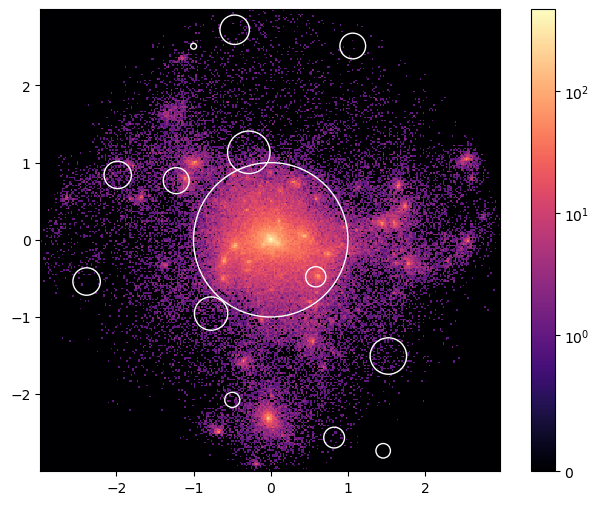

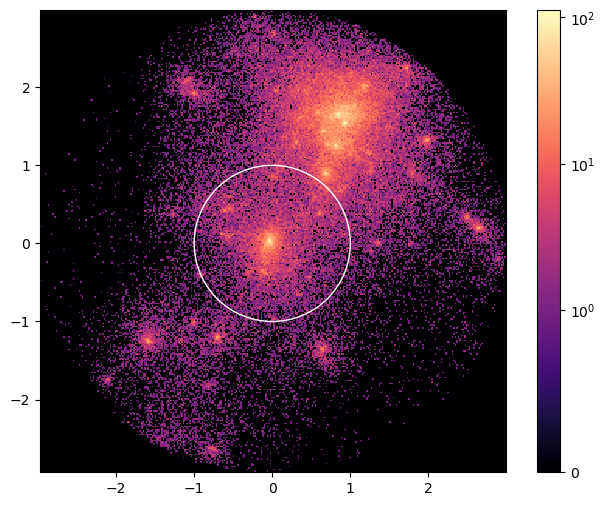

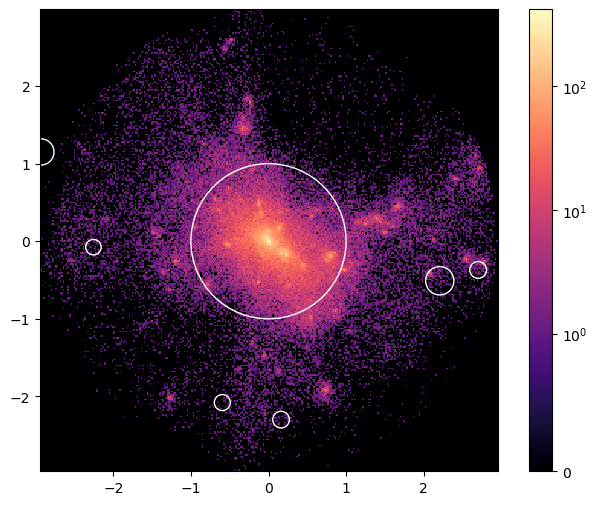

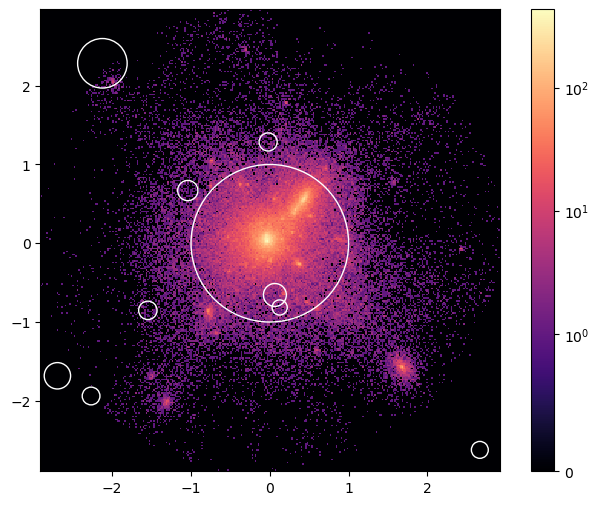

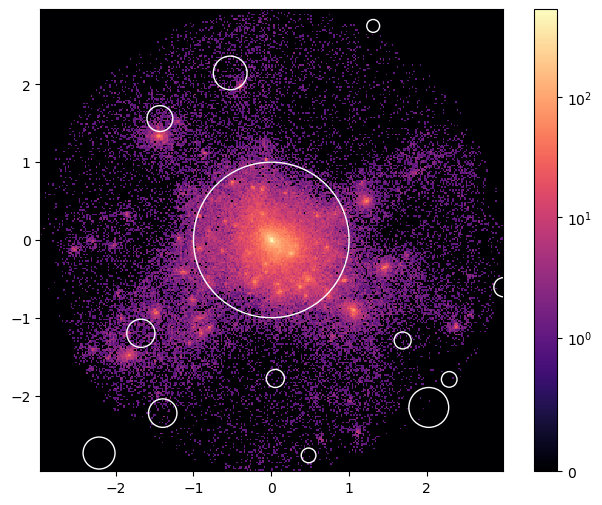

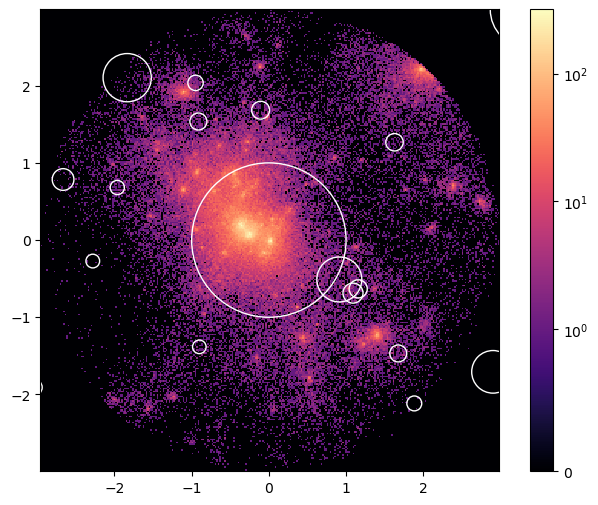

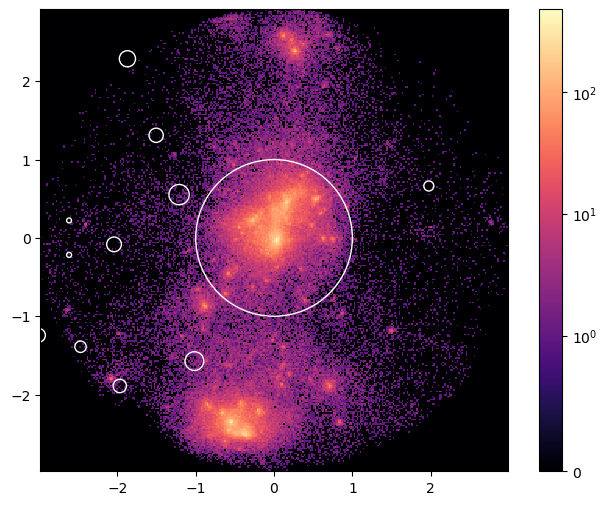

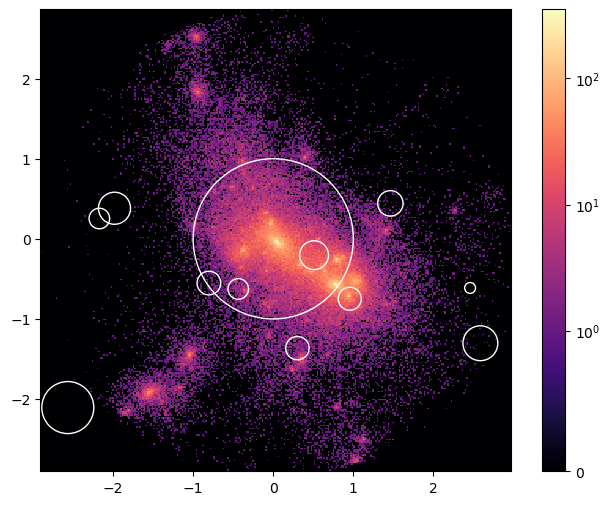

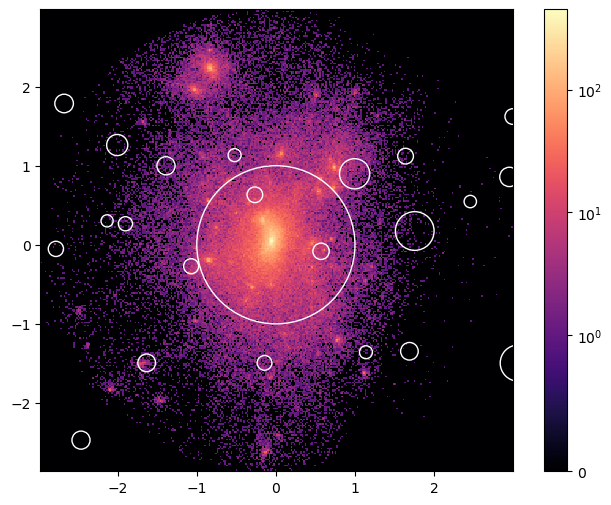

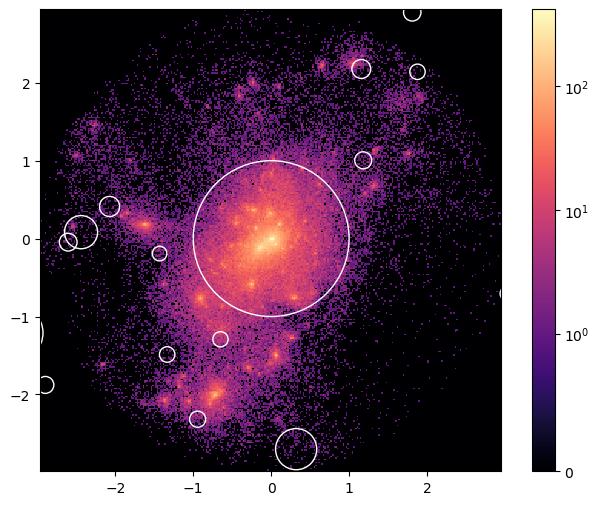

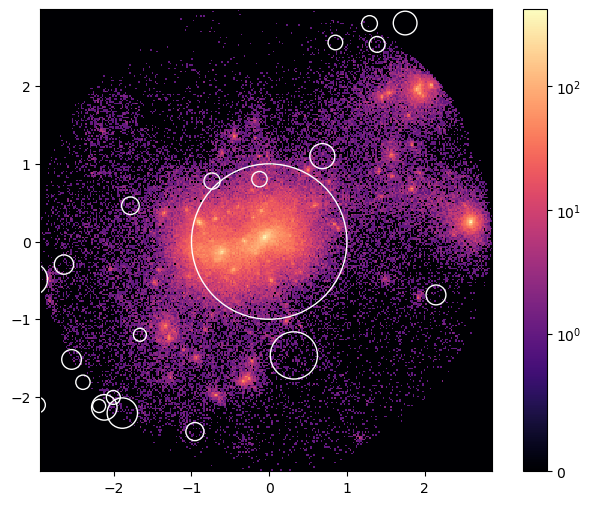

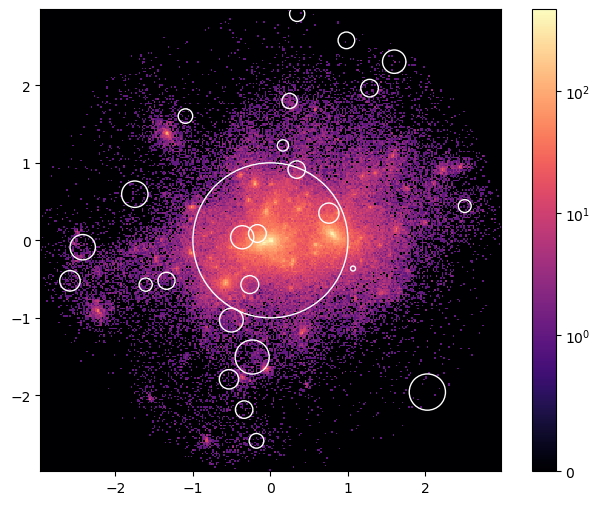

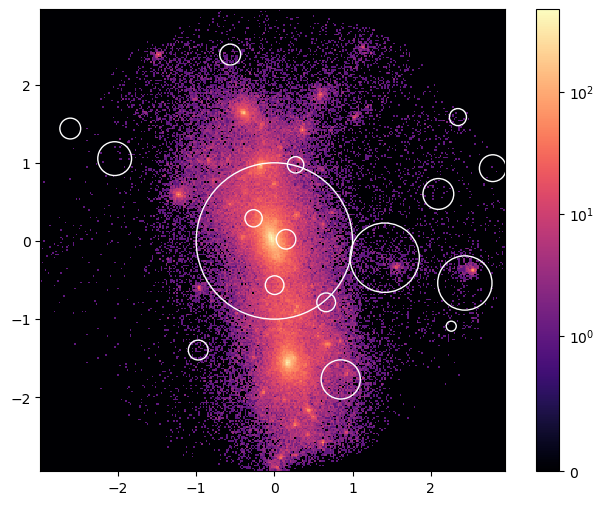

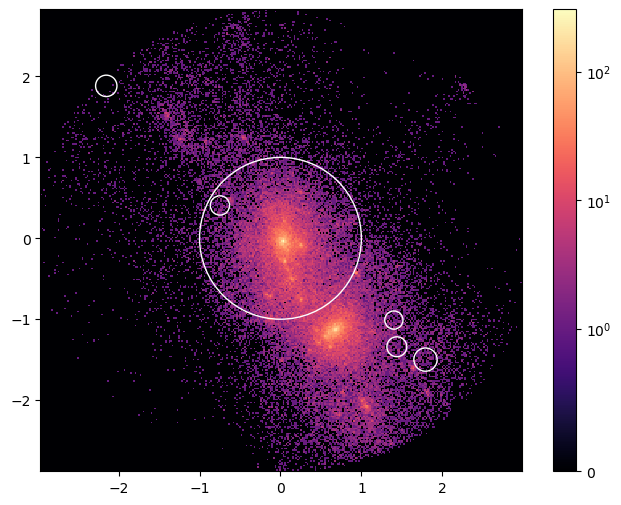

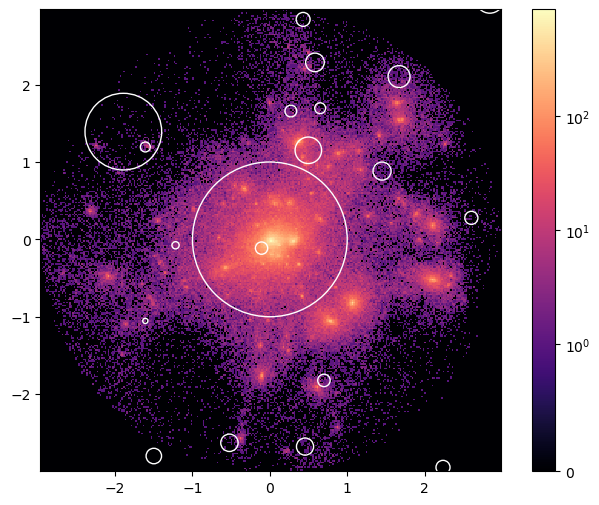

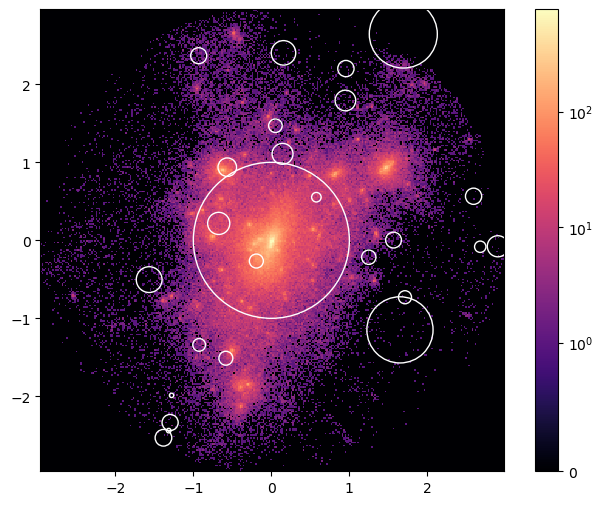

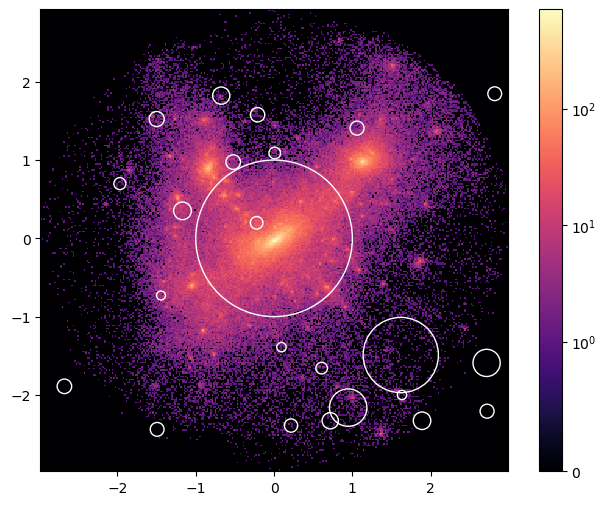

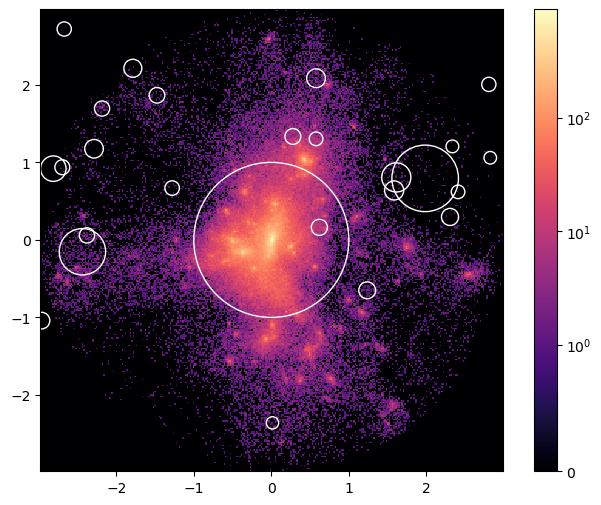

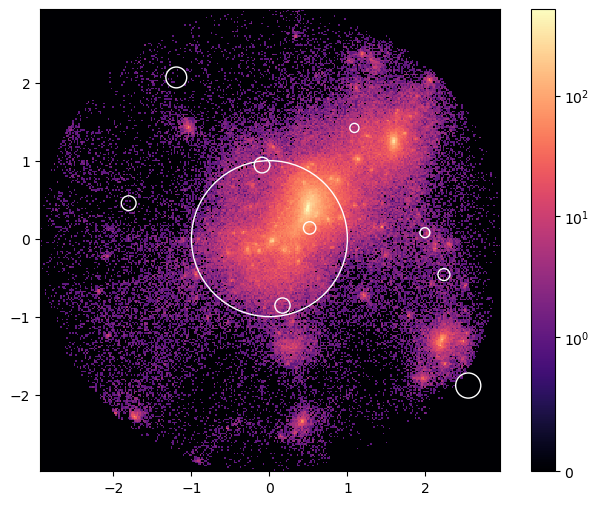

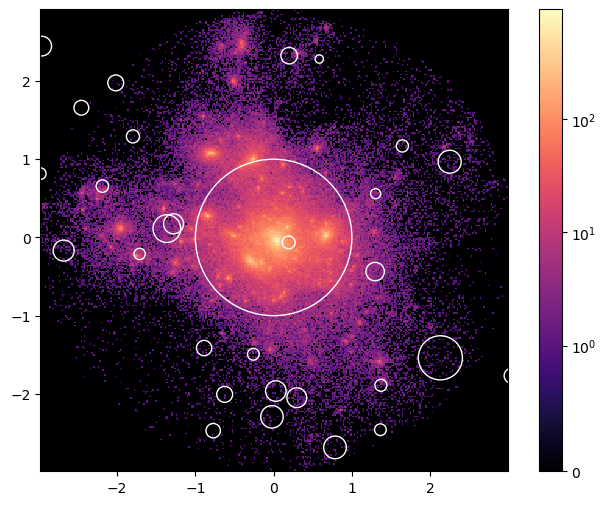

In [16]:
from matplotlib.patches import Circle
for i in range(N):
    #We consider one halo at a time
    itest = top[i]
    ip   = np.array(dm_tree.query_ball_point((haloes[0]['x'][itest],haloes[0]['y'][itest],haloes[0]['z'][itest]), multiplication_factor*haloes[0]['rvir'][itest]))
    norm_x = (displaced_dm[0]['x'][ip]-haloes[0]['x'][itest])
    norm_y = (displaced_dm[0]['y'][ip]-haloes[0]['y'][itest])
    norm_z = (displaced_dm[0]['z'][ip]-haloes[0]['z'][itest])
    #This for loop imposes the periodic boundary conditions
    #Basically, for every particle outside the radius because it's on the other side of the box...
    #...this for loop shifts it so it's back to being by the central halo
    for j in range(len(norm_x)):
        if norm_x[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_x[j] += unit_l_in_Mpc_per_h
        elif norm_x[j] > unit_l_in_Mpc_per_h/2.0:
            norm_x[j] -= unit_l_in_Mpc_per_h
    for j in range(len(norm_y)):
        if norm_y[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_y[j] += unit_l_in_Mpc_per_h
        elif norm_y[j] > unit_l_in_Mpc_per_h/2.0:
            norm_y[j] -= unit_l_in_Mpc_per_h
    for j in range(len(norm_z)):
        if norm_z[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_z[j] += unit_l_in_Mpc_per_h
        elif norm_z[j] > unit_l_in_Mpc_per_h/2.0:
            norm_z[j] -= unit_l_in_Mpc_per_h
    norm_x = norm_x/haloes[0]['rvir'][itest]
    norm_y = norm_y/haloes[0]['rvir'][itest]
    norm_z = norm_z/haloes[0]['rvir'][itest]
    #We develop a histogram
    #weights[iphalo==itest]*haloes[0]['vz'][itest]
    hist, xedges, yedges = np.histogram2d(norm_x, norm_y,bins=bins)
    
    norm = SymLogNorm(linthresh=1.0e0, linscale=1.0, vmin=np.min(hist), vmax=np.max(hist))
    
    iphalo = np.array(halo_tree.query_ball_point((haloes[0]['x'][itest],haloes[0]['y'][itest],haloes[0]['z'][itest]), 3.0*haloes[0]['rvir'][itest]))
    
    norm_x = haloes[0]['x'][iphalo]-haloes[0]['x'][itest]
    norm_y = haloes[0]['y'][iphalo]-haloes[0]['y'][itest]
    norm_z = haloes[0]['z'][iphalo]-haloes[0]['z'][itest]
    virial_radii = haloes[0]['rvir'][iphalo]/haloes[0]['rvir'][itest]
    
    for j in range(len(norm_x)):
        if norm_x[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_x[j] += unit_l_in_Mpc_per_h
        elif norm_x[j] > unit_l_in_Mpc_per_h/2.0:
            norm_x[j] -= unit_l_in_Mpc_per_h
    for j in range(len(norm_y)):
        if norm_y[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_y[j] += unit_l_in_Mpc_per_h
        elif norm_y[j] > unit_l_in_Mpc_per_h/2.0:
            norm_y[j] -= unit_l_in_Mpc_per_h
    for j in range(len(norm_z)):
        if norm_z[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_z[j] += unit_l_in_Mpc_per_h
        elif norm_z[j] > unit_l_in_Mpc_per_h/2.0:
            norm_z[j] -= unit_l_in_Mpc_per_h
    
    plt.figure(figsize=(8, 6))
    plt.imshow(hist, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], norm=norm, cmap='magma')

    for j in range(len(iphalo)):
        circle = Circle((norm_x[j], norm_y[j]), virial_radii[j], color='white', fill=False)
        plt.gca().add_patch(circle)
    
    # Add colorbar
    plt.colorbar()

    plt.show()
    halo_profile[:,:,i] += hist

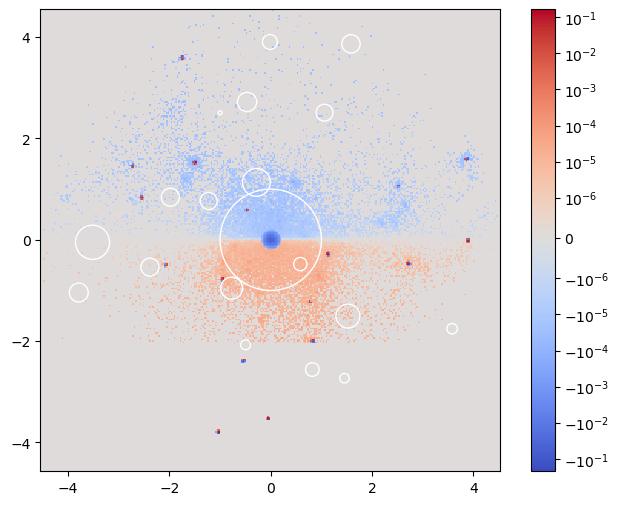

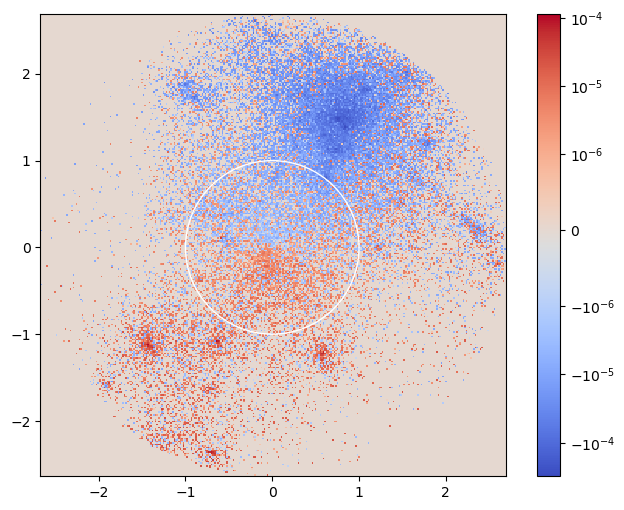

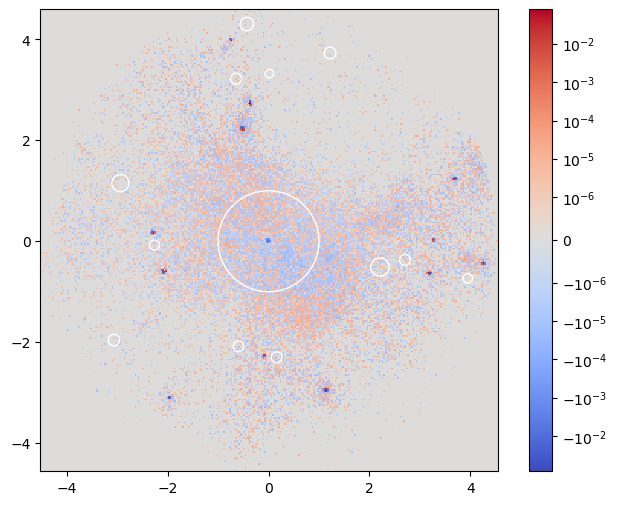

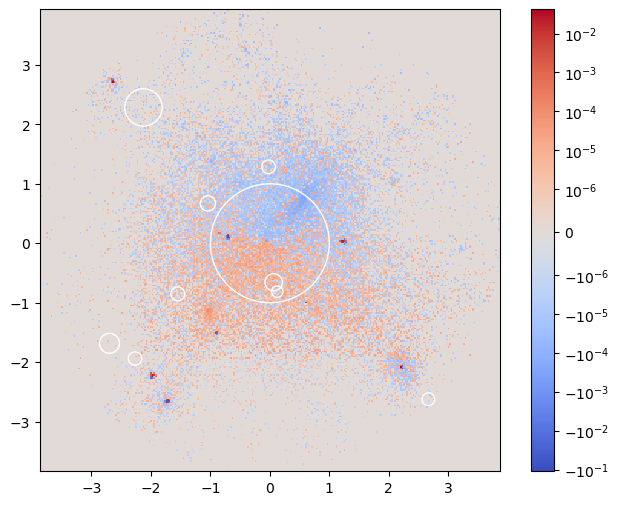

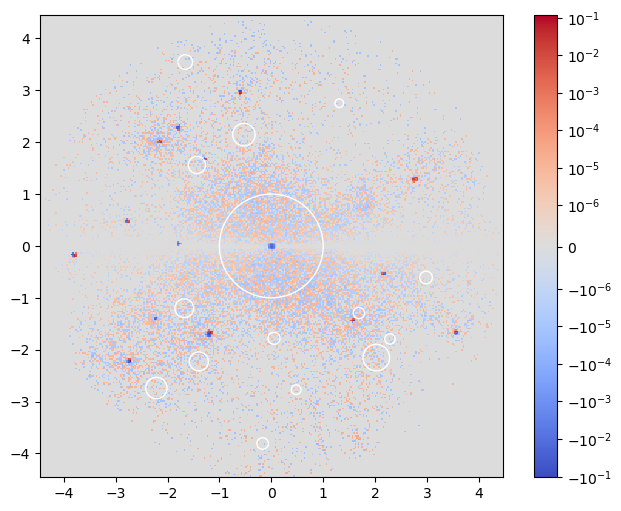

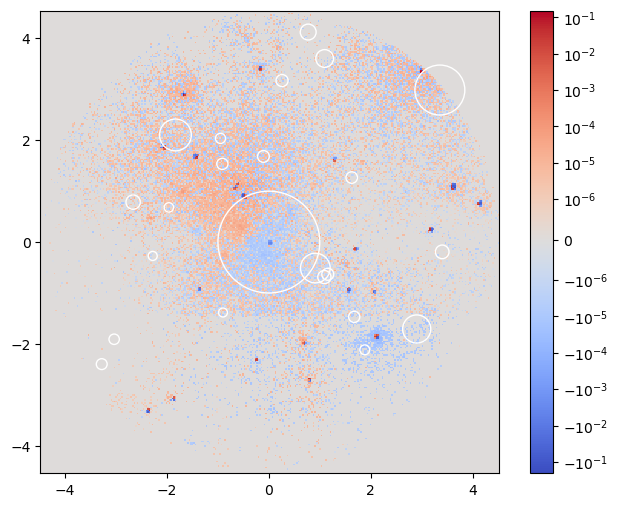

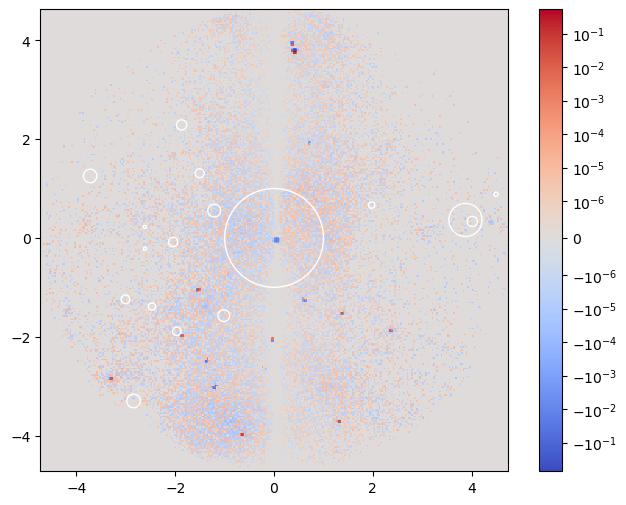

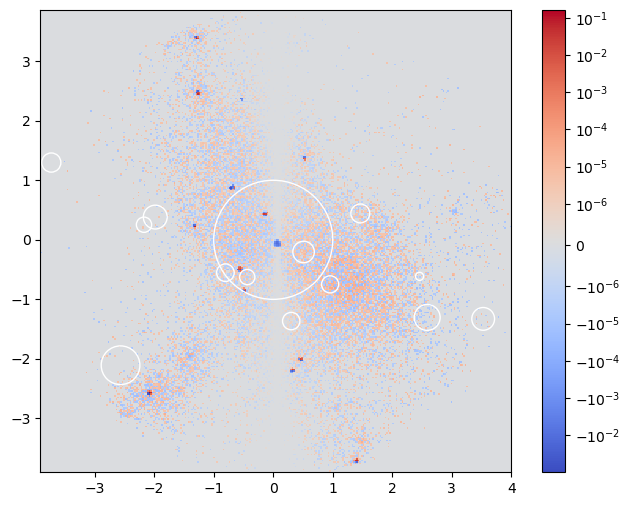

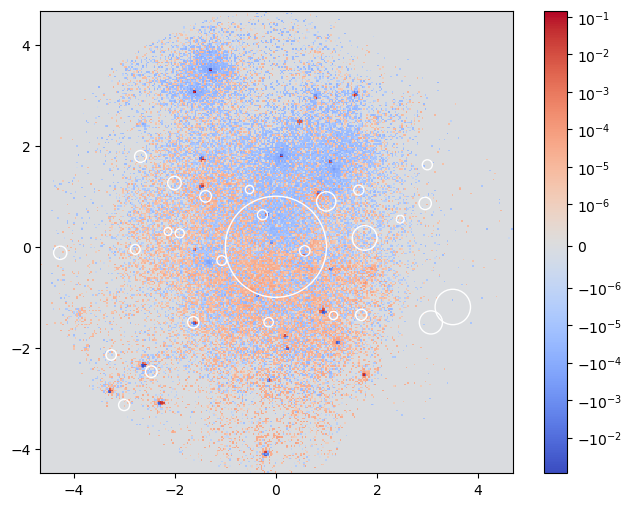

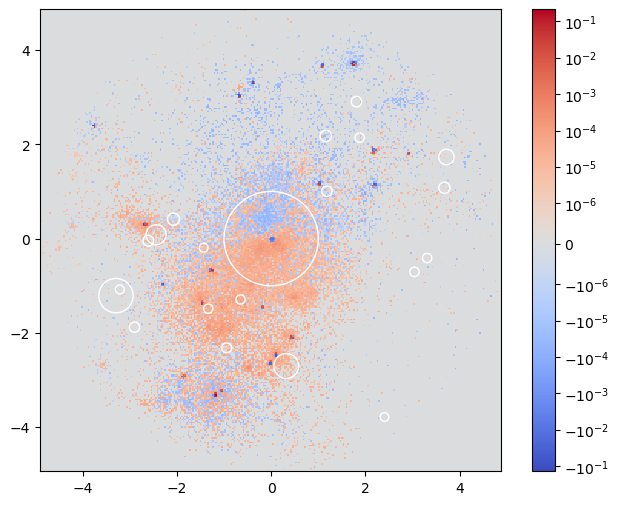

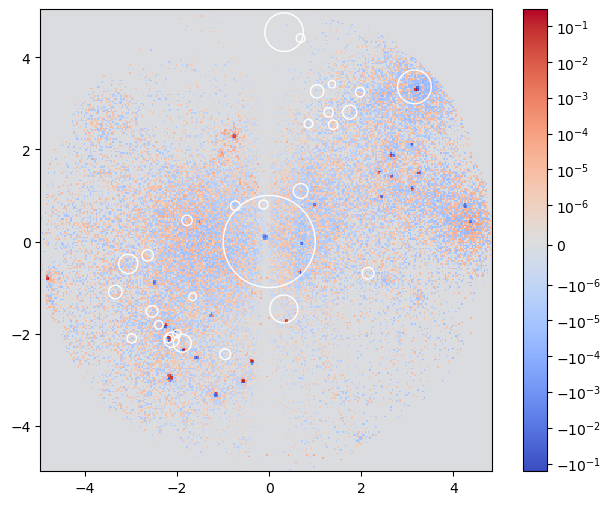

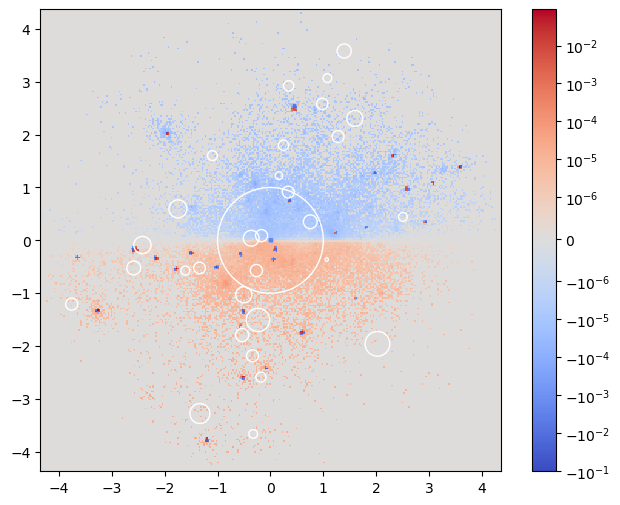

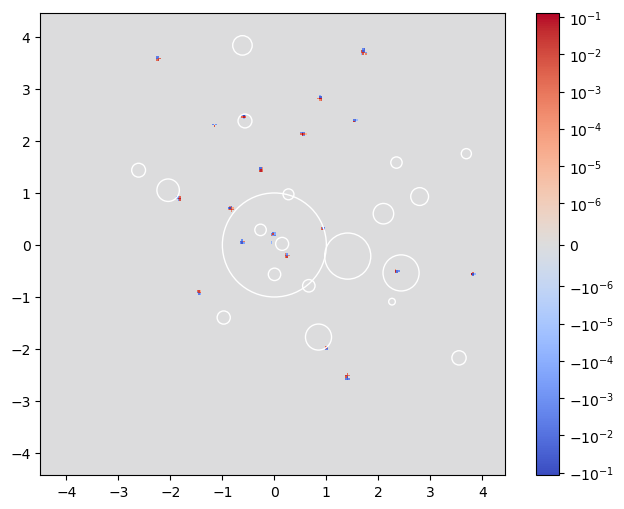

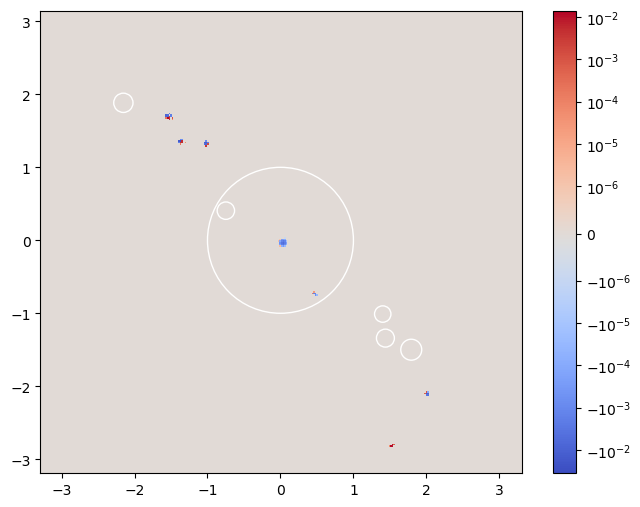

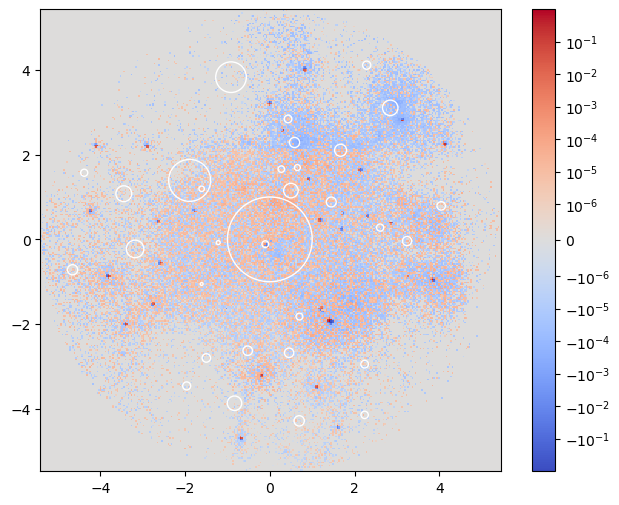

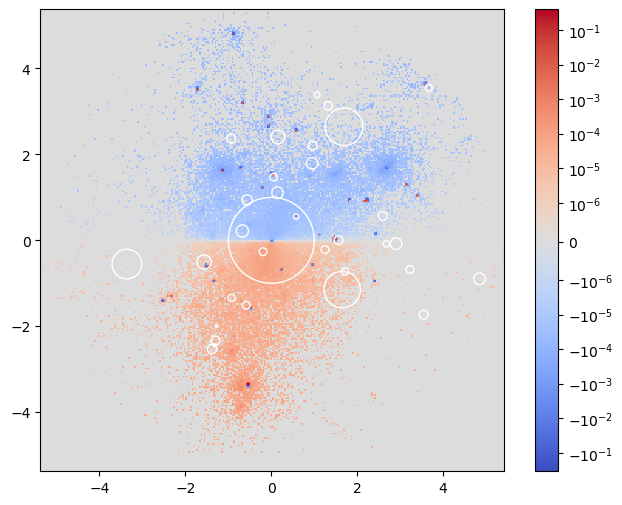

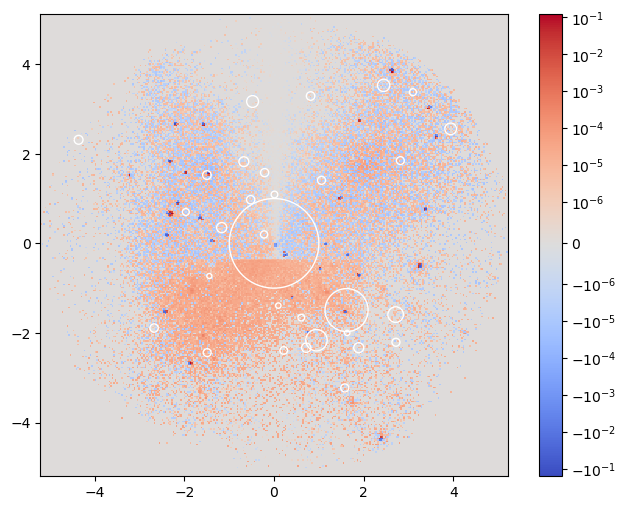

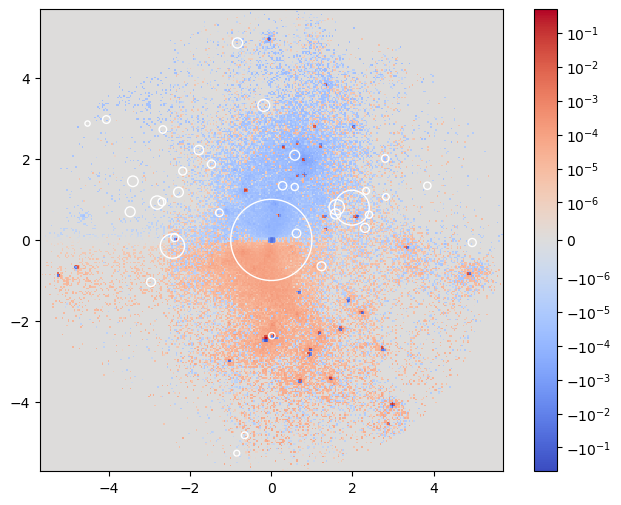

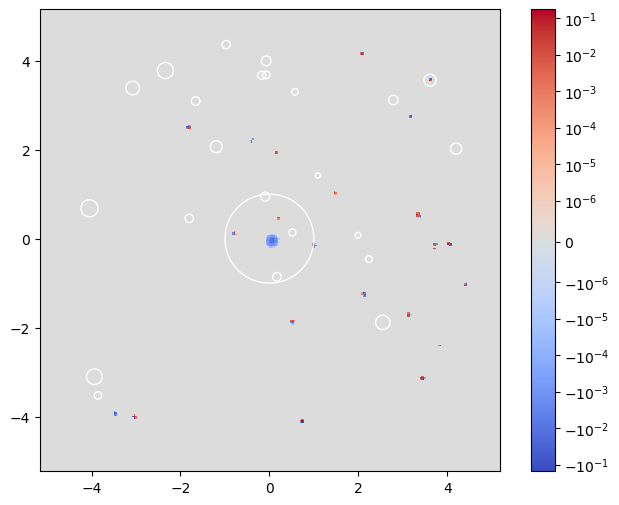

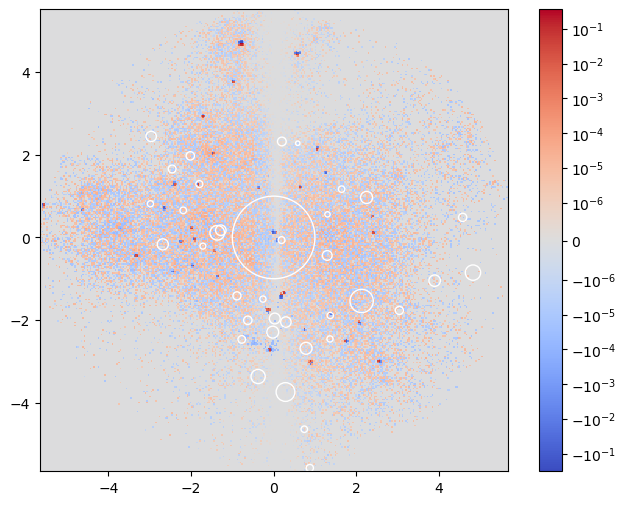

In [17]:
#NOW WE DO THE DIFFERENCE ARRAY, NOW DMO - DM, BUT FIXED TO GIVE DISPLACEMENT FIELDS
for i in range(N):
    #We consider one halo at a time
    itest = top[i]
    ip   = np.array(dmo_tree.query_ball_point((haloes[0]['x'][itest],haloes[0]['y'][itest],haloes[0]['z'][itest]), 3.0*haloes[0]['rvir'][itest]))
    displacement_field_x = displaced_dm[0]['x'][ip] - non_displaced_particles[0]['x'][ip]
    displacement_field_y = displaced_dm[0]['y'][ip] - non_displaced_particles[0]['y'][ip]
    displacement_field_z = displaced_dm[0]['z'][ip] - non_displaced_particles[0]['z'][ip]
    norm_x = (non_displaced_particles[0]['x'][ip]-haloes[0]['x'][itest])
    norm_y = (non_displaced_particles[0]['y'][ip]-haloes[0]['y'][itest])
    norm_z = (non_displaced_particles[0]['z'][ip]-haloes[0]['z'][itest])
    #This for loop imposes the periodic boundary conditions
    #Basically, for every particle outside the radius because it's on the other side of the box...
    #...this for loop shifts it so it's back to being by the central halo
    for j in range(len(norm_x)):
        if norm_x[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_x[j] += unit_l_in_Mpc_per_h
        elif norm_x[j] > unit_l_in_Mpc_per_h/2.0:
            norm_x[j] -= unit_l_in_Mpc_per_h
    for j in range(len(norm_y)):
        if norm_y[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_y[j] += unit_l_in_Mpc_per_h
        elif norm_y[j] > unit_l_in_Mpc_per_h/2.0:
            norm_y[j] -= unit_l_in_Mpc_per_h
    for j in range(len(norm_z)):
        if norm_z[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_z[j] += unit_l_in_Mpc_per_h
        elif norm_z[j] > unit_l_in_Mpc_per_h/2.0:
            norm_z[j] -= unit_l_in_Mpc_per_h
    #Okay now the new stuff. We take each point and want to evaluate whether it's moving towards or away from the origin
    #This is simple: we do the dot product of the vector pointing to the point and the vector at the point
    #If it's positive, the particle is moving away; if it's negative, it's moving towards.
    dot_product = (norm_x * displacement_field_x) + (norm_y * displacement_field_y) + (norm_z * displacement_field_z)
    hist, xedges, yedges = np.histogram2d(norm_x, norm_y,bins=bins,weights=dot_product)
    
    iphalo = np.array(halo_tree.query_ball_point((haloes[0]['x'][itest],haloes[0]['y'][itest],haloes[0]['z'][itest]), 3.0*haloes[0]['rvir'][itest]))
    
    norm_x = haloes[0]['x'][iphalo]-haloes[0]['x'][itest]
    norm_y = haloes[0]['y'][iphalo]-haloes[0]['y'][itest]
    norm_z = haloes[0]['z'][iphalo]-haloes[0]['z'][itest]
    virial_radii = haloes[0]['rvir'][iphalo]/haloes[0]['rvir'][itest]
    
    for j in range(len(norm_x)):
        if norm_x[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_x[j] += unit_l_in_Mpc_per_h
        elif norm_x[j] > unit_l_in_Mpc_per_h/2.0:
            norm_x[j] -= unit_l_in_Mpc_per_h
    for j in range(len(norm_y)):
        if norm_y[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_y[j] += unit_l_in_Mpc_per_h
        elif norm_y[j] > unit_l_in_Mpc_per_h/2.0:
            norm_y[j] -= unit_l_in_Mpc_per_h
    for j in range(len(norm_z)):
        if norm_z[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_z[j] += unit_l_in_Mpc_per_h
        elif norm_z[j] > unit_l_in_Mpc_per_h/2.0:
            norm_z[j] -= unit_l_in_Mpc_per_h
            
    plt.figure(figsize=(8, 6))
    
    norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(hist), vmax=np.max(hist))
    
    plt.imshow(hist, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], norm=norm, cmap='coolwarm')
    
    for j in range(len(iphalo)):
        circle = Circle((norm_x[j], norm_y[j]), virial_radii[j], color='white', fill=False)
        plt.gca().add_patch(circle)
        
    # Add colorbar
    plt.colorbar()

    plt.show()

In [18]:
#Now we do the same thing, but for baryons
displaced_baryons_x = np.load('baryons_only_x.npy')
displaced_baryons_y = np.load('baryons_only_y.npy')
displaced_baryons_z = np.load('baryons_only_z.npy')

In [19]:
displaced_baryons_x[displaced_baryons_x>unit_l_in_Mpc_per_h] -= unit_l_in_Mpc_per_h
displaced_baryons_x[displaced_baryons_x<0.0]  += unit_l_in_Mpc_per_h
displaced_baryons_y[displaced_baryons_y>unit_l_in_Mpc_per_h] -= unit_l_in_Mpc_per_h
displaced_baryons_y[displaced_baryons_y<0.0]  += unit_l_in_Mpc_per_h
displaced_baryons_z[displaced_baryons_z>unit_l_in_Mpc_per_h] -= unit_l_in_Mpc_per_h
displaced_baryons_z[displaced_baryons_z<0.0]  += unit_l_in_Mpc_per_h

In [ ]:
baryon_tree = spatial.cKDTree(list(zip(displaced_baryons_x,displaced_baryons_y,displaced_baryons_z)), leafsize=100, boxsize=np.array([unit_l_in_Mpc_per_h, unit_l_in_Mpc_per_h, unit_l_in_Mpc_per_h]))

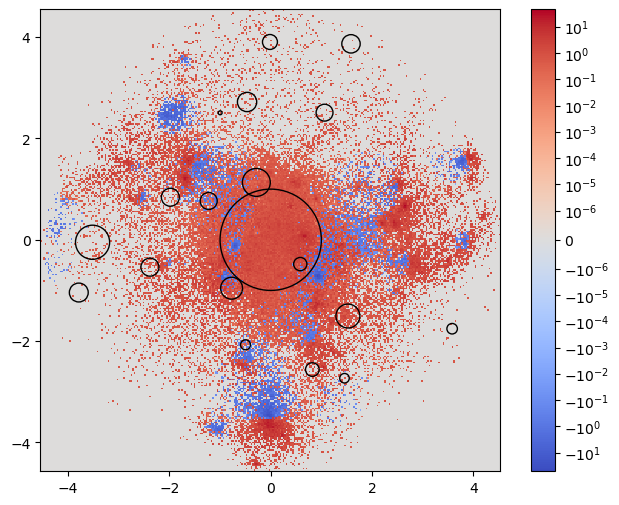

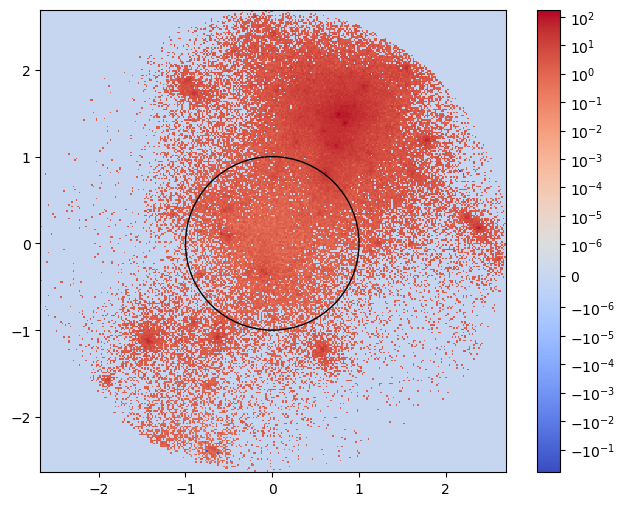

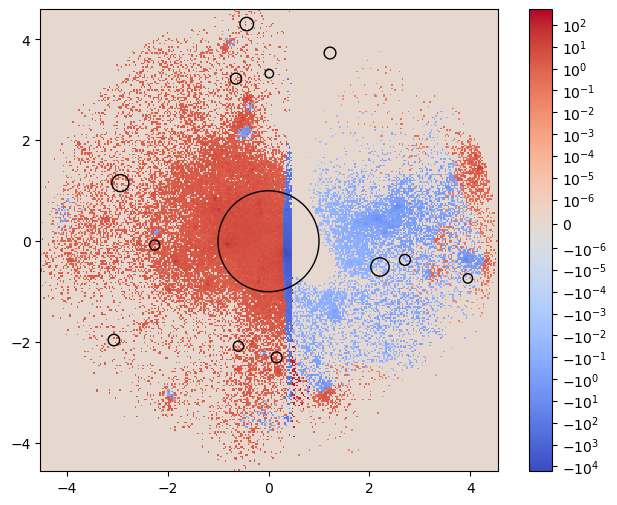

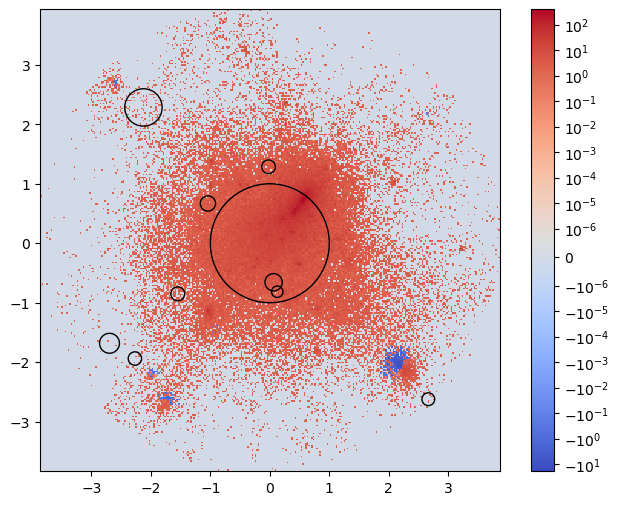

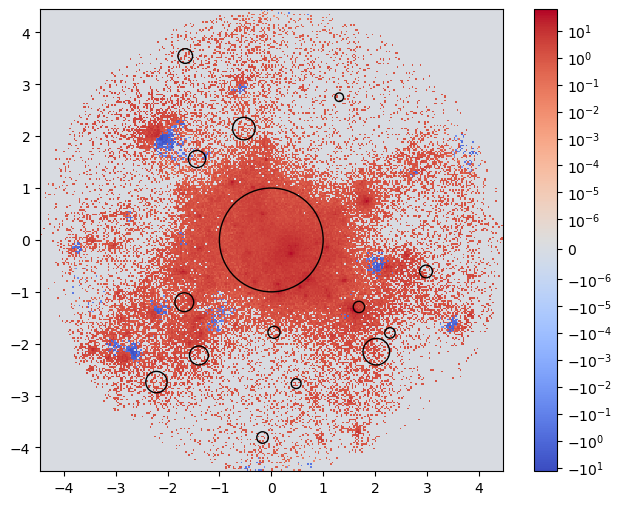

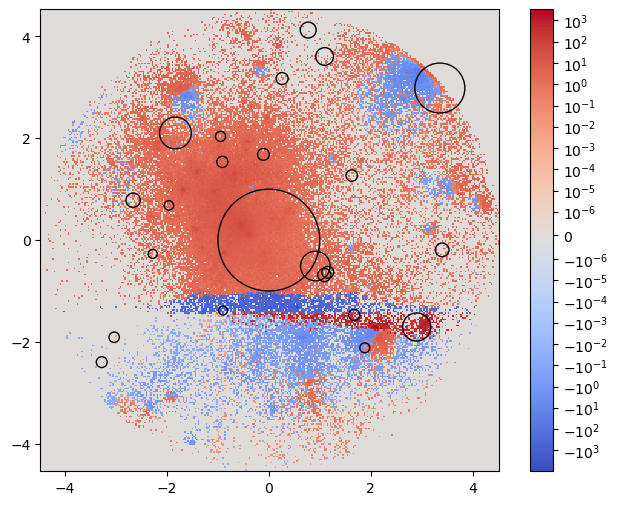

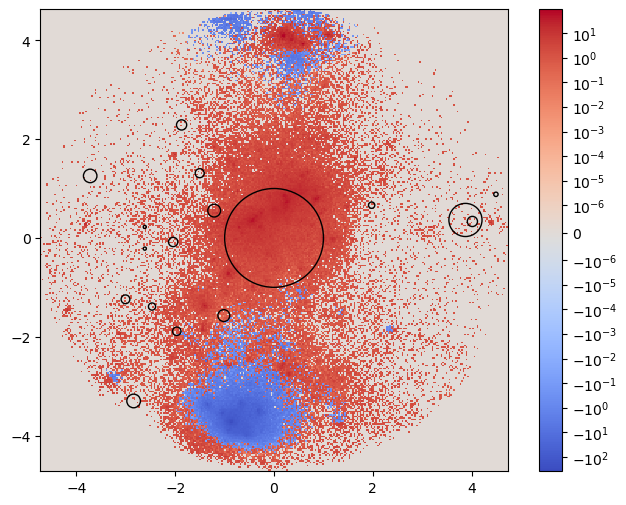

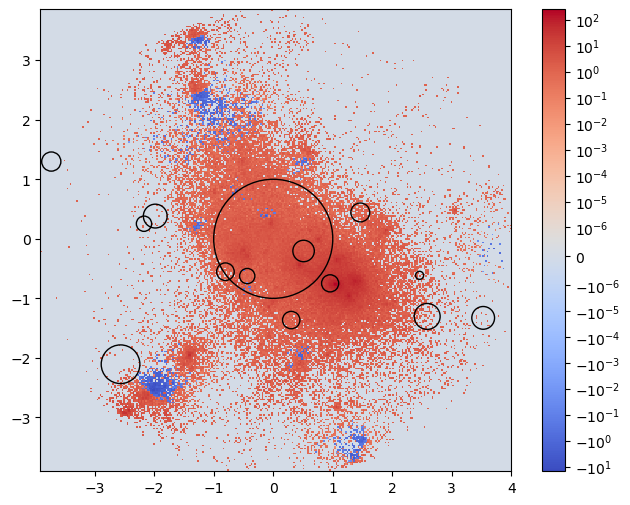

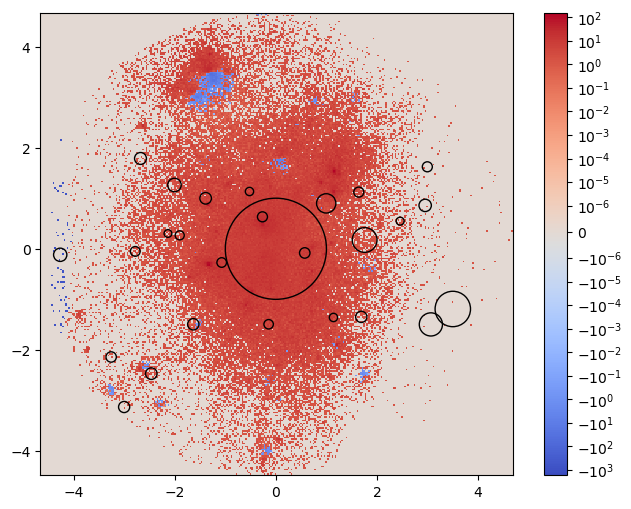

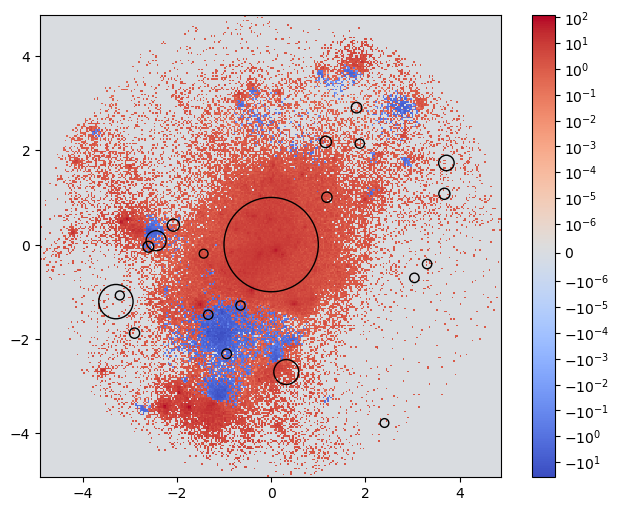

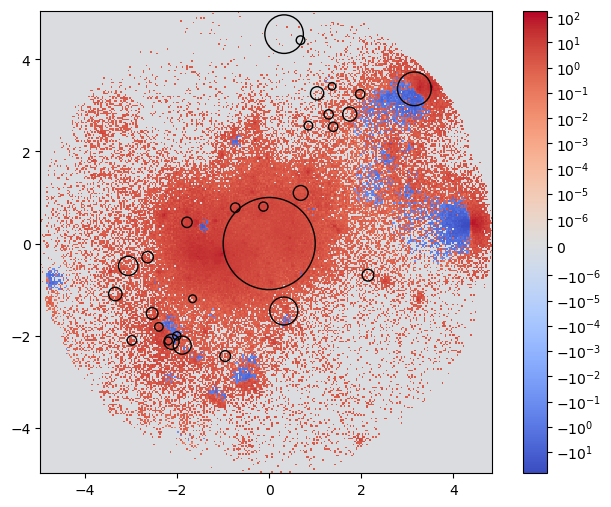

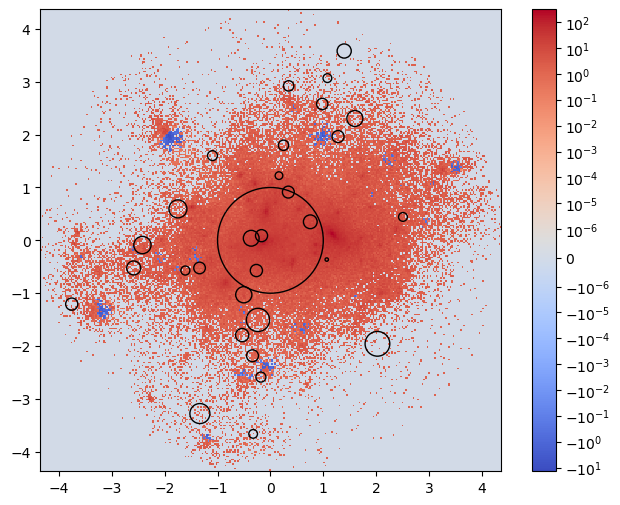

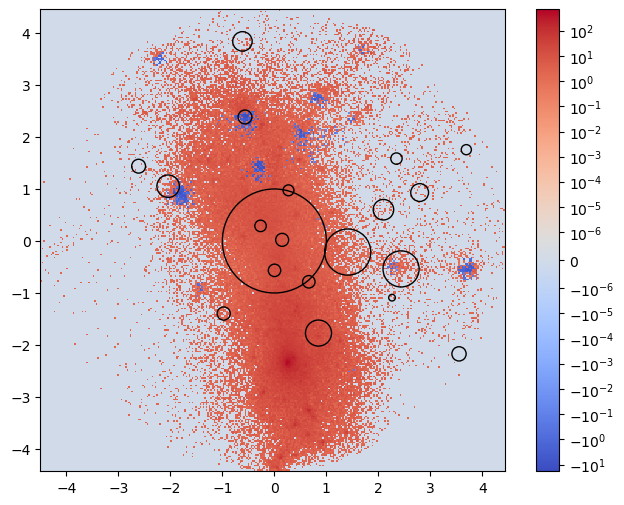

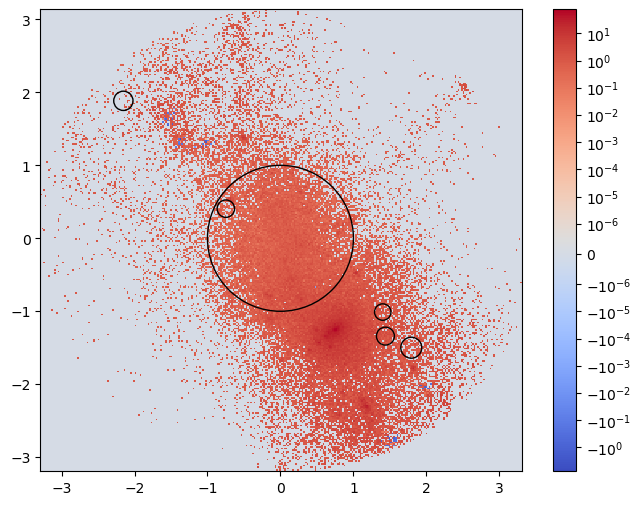

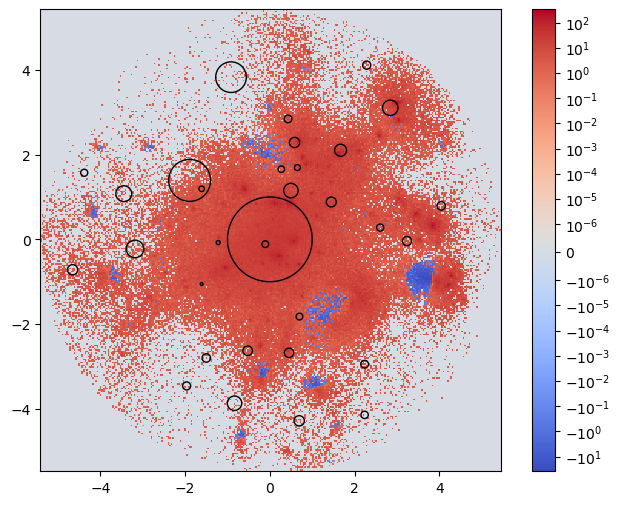

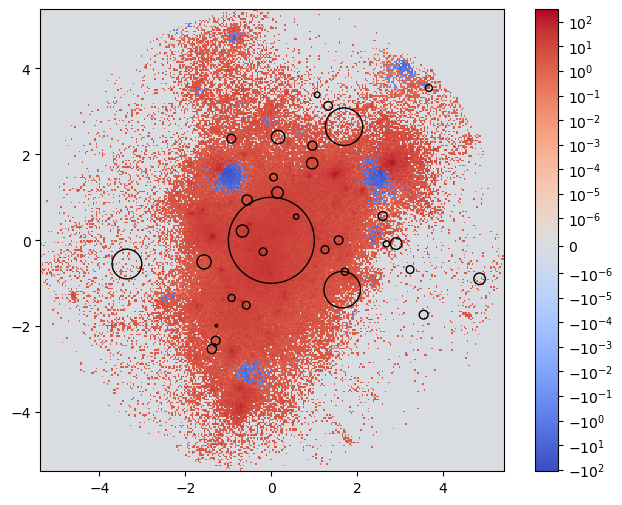

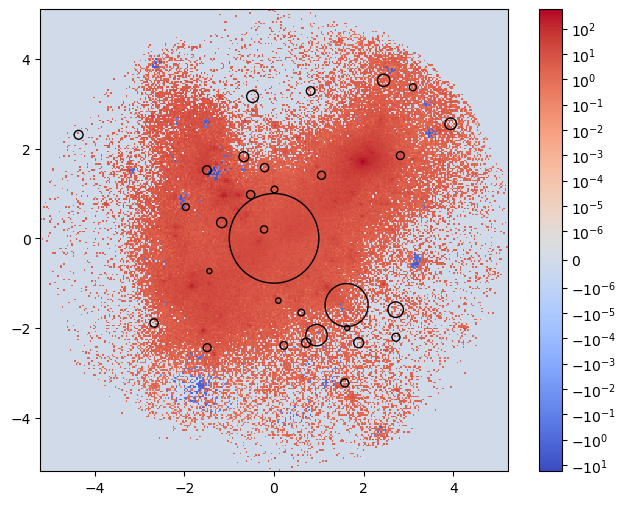

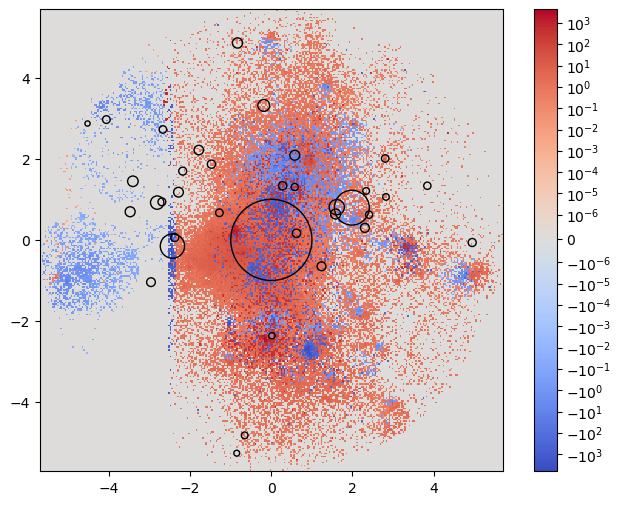

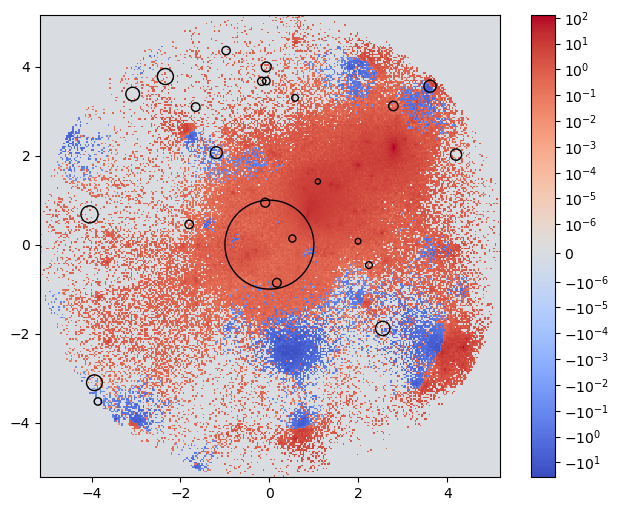

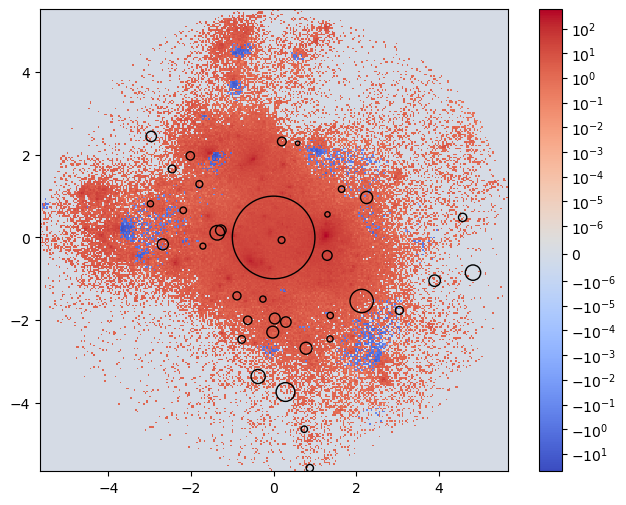

In [20]:
for i in range(N):
    #We consider one halo at a time
    itest = top[i]
    ip   = np.array(dmo_tree.query_ball_point((haloes[0]['x'][itest],haloes[0]['y'][itest],haloes[0]['z'][itest]), 3.0*haloes[0]['rvir'][itest]))
    displacement_field_x = displaced_baryons_x[ip] - non_displaced_particles[0]['x'][ip]
    displacement_field_y = displaced_baryons_y[ip] - non_displaced_particles[0]['y'][ip]
    displacement_field_z = displaced_baryons_z[ip] - non_displaced_particles[0]['z'][ip]
    norm_x = (non_displaced_particles[0]['x'][ip]-haloes[0]['x'][itest])
    norm_y = (non_displaced_particles[0]['y'][ip]-haloes[0]['y'][itest])
    norm_z = (non_displaced_particles[0]['z'][ip]-haloes[0]['z'][itest])
    #This for loop imposes the periodic boundary conditions
    #Basically, for every particle outside the radius because it's on the other side of the box...
    #...this for loop shifts it so it's back to being by the central halo
    for j in range(len(norm_x)):
        if norm_x[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_x[j] += unit_l_in_Mpc_per_h
        elif norm_x[j] > unit_l_in_Mpc_per_h/2.0:
            norm_x[j] -= unit_l_in_Mpc_per_h
    for j in range(len(norm_y)):
        if norm_y[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_y[j] += unit_l_in_Mpc_per_h
        elif norm_y[j] > unit_l_in_Mpc_per_h/2.0:
            norm_y[j] -= unit_l_in_Mpc_per_h
    for j in range(len(norm_z)):
        if norm_z[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_z[j] += unit_l_in_Mpc_per_h
        elif norm_z[j] > unit_l_in_Mpc_per_h/2.0:
            norm_z[j] -= unit_l_in_Mpc_per_h
    #Okay now the new stuff. We take each point and want to evaluate whether it's moving towards or away from the origin
    #This is simple: we do the dot product of the vector pointing to the point and the vector at the point
    #If it's positive, the particle is moving away; if it's negative, it's moving towards.
    dot_product = (norm_x * displacement_field_x) + (norm_y * displacement_field_y) + (norm_z * displacement_field_z)
    hist, xedges, yedges = np.histogram2d(norm_x, norm_y,bins=bins,weights=dot_product)
    
    iphalo = np.array(halo_tree.query_ball_point((haloes[0]['x'][itest],haloes[0]['y'][itest],haloes[0]['z'][itest]), 3.0*haloes[0]['rvir'][itest]))
    
    norm_x = haloes[0]['x'][iphalo]-haloes[0]['x'][itest]
    norm_y = haloes[0]['y'][iphalo]-haloes[0]['y'][itest]
    norm_z = haloes[0]['z'][iphalo]-haloes[0]['z'][itest]
    virial_radii = haloes[0]['rvir'][iphalo]/haloes[0]['rvir'][itest]
    
    for j in range(len(norm_x)):
        if norm_x[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_x[j] += unit_l_in_Mpc_per_h
        elif norm_x[j] > unit_l_in_Mpc_per_h/2.0:
            norm_x[j] -= unit_l_in_Mpc_per_h
    for j in range(len(norm_y)):
        if norm_y[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_y[j] += unit_l_in_Mpc_per_h
        elif norm_y[j] > unit_l_in_Mpc_per_h/2.0:
            norm_y[j] -= unit_l_in_Mpc_per_h
    for j in range(len(norm_z)):
        if norm_z[j] < -unit_l_in_Mpc_per_h/2.0:
            norm_z[j] += unit_l_in_Mpc_per_h
        elif norm_z[j] > unit_l_in_Mpc_per_h/2.0:
            norm_z[j] -= unit_l_in_Mpc_per_h
            
    plt.figure(figsize=(8, 6))
    
    norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(hist), vmax=np.max(hist))
    
    plt.imshow(hist, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], norm=norm, cmap='coolwarm')
    
    for j in range(len(iphalo)):
        circle = Circle((norm_x[j], norm_y[j]), virial_radii[j], color='black', fill=False)
        plt.gca().add_patch(circle)
        
    # Add colorbar
    plt.colorbar()

    plt.show()